# Notebook 3: Ensemble Classification & Decision Tree Regression

**Module:** Machine Learning Coursework  
**Purpose:** This notebook is divided into two parts:
- **Part 1** — Ensemble Classification using a Soft VotingClassifier (Logistic Regression + KNN as base learners)
- **Part 2** — Decision Tree Regression on approved loans, comparing a full tree with a depth-limited tree

---

# PART 1: Ensemble Classification

A **VotingClassifier** combines predictions from multiple base learners. Using `voting='soft'` averages the predicted probabilities from each base learner before making a final decision, which typically yields better calibrated predictions than hard (majority-vote) voting.

**Base learners:**
- Logistic Regression — a linear probabilistic classifier  
- K-Nearest Neighbours (KNN) — a non-parametric distance-based classifier

## 1. Load Preprocessed Classification Data

Notebook 1 is executed via `%run`, which makes all its output variables (`X_classification_scaled`, `y_classification`, etc.) available in this kernel's namespace.

All libraries imported successfully.
Dataset loaded successfully.
Dataset shape: 58645 rows x 13 columns
<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  str    
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  str    
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  str    
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-n

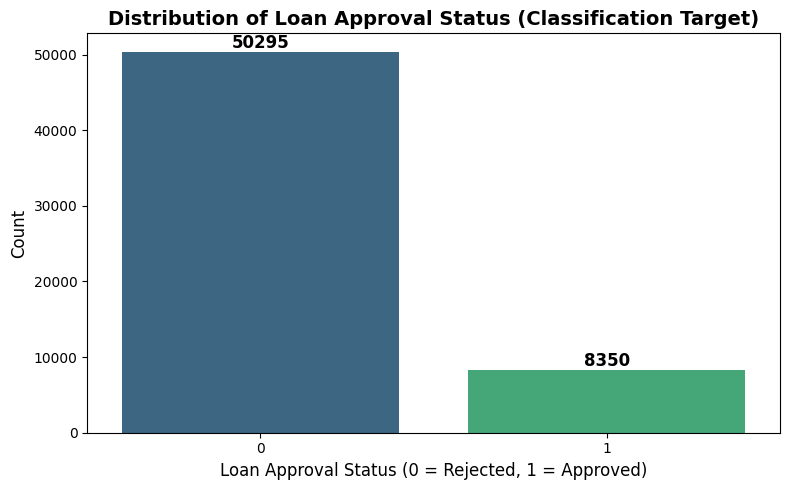


Class Distribution (percentage):
loan_approval_status
0    85.76
1    14.24
Name: proportion, dtype: float64


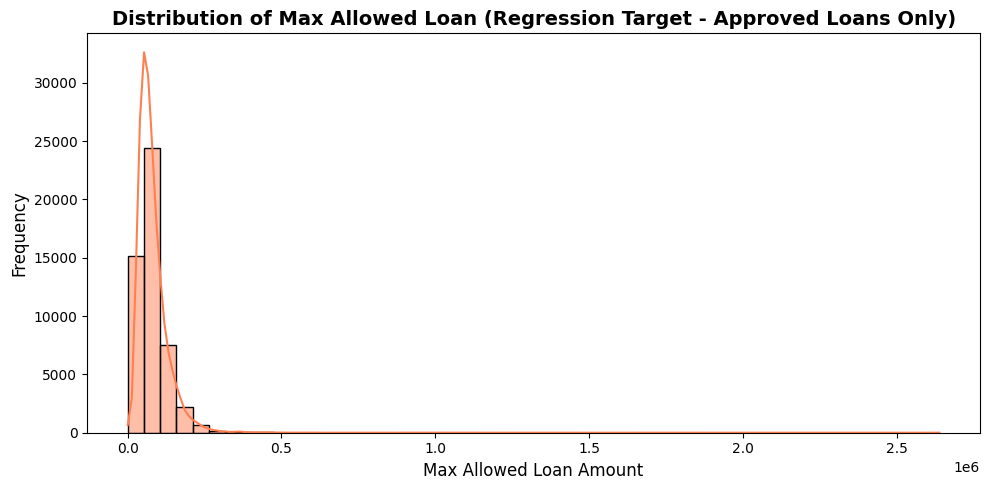


Regression Target Statistics (non-zero max_allowed_loan):
count    5.029200e+04
mean     8.139253e+04
std      5.812145e+04
min      2.320000e+02
25%      4.911050e+04
50%      6.943150e+04
75%      9.899100e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64
Preprocessing complete. Classification variables loaded:
  X_classification_scaled : (58645, 10)
  y_classification        : (58645,)


In [1]:
# Execute Notebook 1 to run the full preprocessing pipeline
%run loan_data_preprocessing.ipynb

# Confirm the classification variables are available
print("Preprocessing complete. Classification variables loaded:")

# Print the shape of the scaled feature matrix
print(f"  X_classification_scaled : {X_classification_scaled.shape}")

# Print the shape of the classification target vector
print(f"  y_classification        : {y_classification.shape}")

## 2. Import Libraries

All libraries for ensemble modelling, evaluation, plotting and utilities are imported here.

In [2]:
# Import numpy for numerical array operations
import numpy as np

# Import pandas for DataFrame manipulation
import pandas as pd

# Import matplotlib for creating plots
import matplotlib.pyplot as plt

# Import seaborn for enhanced statistical visualisations
import seaborn as sns

# Import train_test_split for partitioning data
from sklearn.model_selection import train_test_split

# Import Logistic Regression as the first base learner
from sklearn.linear_model import LogisticRegression

# Import KNeighborsClassifier as the second base learner
from sklearn.neighbors import KNeighborsClassifier

# Import VotingClassifier to combine base learner predictions
from sklearn.ensemble import VotingClassifier

# Import confusion_matrix to assess prediction errors
from sklearn.metrics import confusion_matrix

# Import classification_report for per-class metrics breakdown
from sklearn.metrics import classification_report

# Import individual metric functions for explicit reporting
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Import roc_auc_score to compute area under the ROC curve
from sklearn.metrics import roc_auc_score

# Import roc_curve to calculate ROC coordinates for plotting
from sklearn.metrics import roc_curve

# Import DecisionTreeRegressor for Part 2
from sklearn.tree import DecisionTreeRegressor

# Import plot_tree for visualising decision tree structure
from sklearn.tree import plot_tree

# Import regression metrics for Part 2 evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Import warnings module to suppress non-critical messages
import warnings

# Suppress all warnings to keep output clean
warnings.filterwarnings('ignore')

# Confirm all imports completed without error
print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Train-Test Split (Classification)

The same split parameters as Notebook 2 are used to ensure comparability:
- **`test_size=0.2`** — 20% of data held out for evaluation
- **`stratify=y_classification`** — preserves class imbalance ratio in both splits
- **`random_state=42`** — guarantees reproducibility

In [3]:
# Split features and labels into training and test sets
# Using identical parameters to Notebook 2 for consistent comparison
X_train, X_test, y_train, y_test = train_test_split(
    X_classification_scaled,    # scaled feature matrix from Notebook 1
    y_classification,           # binary target: 0=Rejected, 1=Approved
    test_size=0.2,              # reserve 20% for testing
    stratify=y_classification,  # preserve class proportions in each split
    random_state=42             # fix random seed for reproducibility
)

# Print the size of the training set
print(f"Training set size  : {X_train.shape[0]} samples")

# Print the size of the test set
print(f"Test set size      : {X_test.shape[0]} samples")

# Print the number of features
print(f"Number of features : {X_train.shape[1]}")

# Print class distribution in the training set for reference
print("\nClass distribution in training set:")

# Display the count of each class label in the training target
print(y_train.value_counts())

Training set size  : 46916 samples
Test set size      : 11729 samples
Number of features : 10

Class distribution in training set:
loan_approval_status
0    40236
1     6680
Name: count, dtype: int64


## 4. Build VotingClassifier (Soft Voting)

A **VotingClassifier** with `voting='soft'` averages the predicted class **probabilities** from each base learner before making a final decision. This typically outperforms hard voting because it exploits confidence information from each model.

**Base learners:**
1. **Logistic Regression** — `max_iter=1000` to ensure convergence
2. **K-Nearest Neighbours** — default 5 neighbours

In [4]:
# Instantiate Logistic Regression as the first base learner
# max_iter=1000 ensures the solver converges on this dataset
lr_estimator = LogisticRegression(max_iter=1000, random_state=42)

# Instantiate KNN as the second base learner (default: 5 neighbours)
knn_estimator = KNeighborsClassifier()

# Create the VotingClassifier with soft voting
# soft voting averages predicted probabilities instead of counts
voting_clf = VotingClassifier(
    # Provide named base learner pairs (name, estimator)
    estimators=[
        ('logistic_regression', lr_estimator),
        ('knn', knn_estimator)
    ],
    # Use soft voting to average class probabilities across base learners
    voting='soft'
)

# Confirm the ensemble model is built and ready
print("VotingClassifier (soft) built with base learners:")

# Print the name of the first base learner
print("  Base learner 1: Logistic Regression (max_iter=1000)")

# Print the name of the second base learner
print("  Base learner 2: K-Nearest Neighbours (n_neighbors=5)")

VotingClassifier (soft) built with base learners:
  Base learner 1: Logistic Regression (max_iter=1000)
  Base learner 2: K-Nearest Neighbours (n_neighbors=5)


## 5. Train the Ensemble

The VotingClassifier fits each named base learner on the training data simultaneously.

In [5]:
# Train the VotingClassifier on the training data
# This internally fits both Logistic Regression and KNN
voting_clf.fit(X_train, y_train)

# Confirm that the ensemble training completed successfully
print("VotingClassifier (Soft) trained successfully.")

VotingClassifier (Soft) trained successfully.


## 6. Evaluate Ensemble Model

The ensemble is evaluated using the following metrics:
- **Confusion Matrix** — visualised as a heatmap
- **Classification Report** — per-class precision, recall, F1 (`zero_division=0`)
- **Accuracy** — overall correctness
- **Recall (Reject class)** — how well the model identifies rejections (class 0)
- **Precision** — positive predictive value (`zero_division=0`)
- **F1-Score** — harmonic mean of precision and recall
- **AUC-ROC** — overall discriminatory power using predicted probabilities

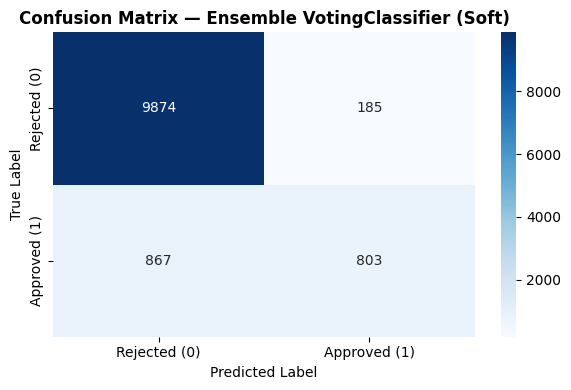


[Classification Report]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     10059
           1       0.81      0.48      0.60      1670

    accuracy                           0.91     11729
   macro avg       0.87      0.73      0.78     11729
weighted avg       0.90      0.91      0.90     11729

  ENSEMBLE MODEL METRICS
Accuracy                          : 0.9103
Recall (Reject class):              0.9816
Recall (Approve class):             0.4808
Precision                         : 0.8128
F1-Score                          : 0.6042
AUC-ROC                           : 0.8970


In [6]:
# Generate class label predictions from the trained ensemble
y_pred = voting_clf.predict(X_test)

# Generate predicted probabilities for the positive class (Approved=1)
# Used to compute AUC-ROC
y_proba = voting_clf.predict_proba(X_test)[:, 1]

# ── Confusion Matrix ──────────────────────────────────────────────────────

# Compute the confusion matrix from true and predicted labels
cm = confusion_matrix(y_test, y_pred)

# Create a matplotlib figure for the confusion matrix heatmap
plt.figure(figsize=(6, 4))

# Draw the annotated heatmap with class labels
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Rejected (0)', 'Approved (1)'],
    yticklabels=['Rejected (0)', 'Approved (1)']
)

# Set the title of the confusion matrix plot
plt.title('Confusion Matrix — Ensemble VotingClassifier (Soft)', fontsize=12, fontweight='bold')

# Label the x-axis
plt.xlabel('Predicted Label', fontsize=10)

# Label the y-axis
plt.ylabel('True Label', fontsize=10)

# Apply tight layout to prevent label clipping
plt.tight_layout()

# Display the confusion matrix heatmap
plt.show()

# ── Classification Report ─────────────────────────────────────────────────

# Print a section header for the classification report
print("\n[Classification Report]")

# Print precision, recall, F1, support for each class
# zero_division=0 prevents division-by-zero on empty prediction sets
print(classification_report(y_test, y_pred, zero_division=0))

# ── Individual Metrics ────────────────────────────────────────────────────

# Compute overall accuracy (fraction of correct predictions)
acc = accuracy_score(y_test, y_pred)

# Compute recall for the REJECT class (class 0) using pos_label=0
# This shows how well the model identifies rejected loans
rec_reject = recall_score(y_test, y_pred, pos_label=0, zero_division=0)

# Compute recall for the APPROVED class (class 1) — standard positive class
rec_approve = recall_score(y_test, y_pred, pos_label=1, zero_division=0)

# Compute precision for the positive class; zero_division=0 for safety
prec = precision_score(y_test, y_pred, zero_division=0)

# Compute F1-score for the positive class
f1 = f1_score(y_test, y_pred, zero_division=0)

# Compute AUC-ROC using predicted probabilities for the positive class
auc = roc_auc_score(y_test, y_proba)

# Print a summary metrics header
print("=" * 55)
print("  ENSEMBLE MODEL METRICS")
print("=" * 55)

# Print overall accuracy
print(f"Accuracy                          : {acc:.4f}")

# Print recall for the reject class clearly labelled
print(f"Recall (Reject class):              {rec_reject:.4f}")

# Print recall for the approved class for context
print(f"Recall (Approve class):             {rec_approve:.4f}")

# Print precision for the positive class
print(f"Precision                         : {prec:.4f}")

# Print F1-score for the positive class
print(f"F1-Score                          : {f1:.4f}")

# Print AUC-ROC in the required format
print(f"AUC-ROC                           : {auc:.4f}")

# Print closing separator
print("=" * 55)

## 7. ROC Curve — Ensemble Model

The ROC curve visualises the trade-off between True Positive Rate (Recall) and False Positive Rate across all classification thresholds. A larger area under the curve (AUC) indicates better separation between classes.

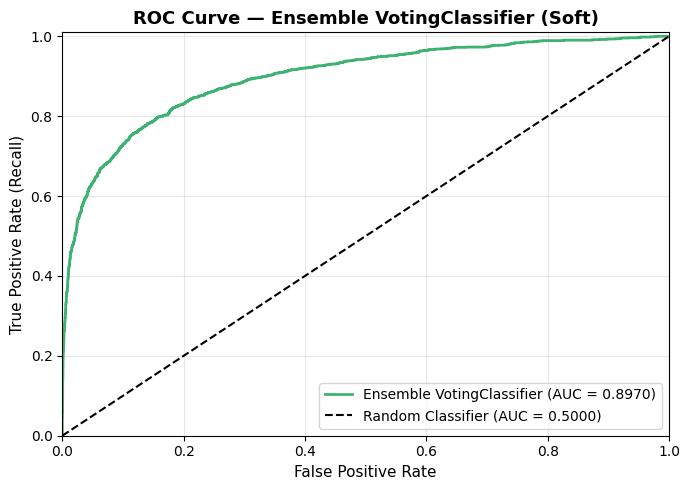

Ensemble VotingClassifier AUC-ROC : 0.8970


In [7]:
# Compute the false positive rate, true positive rate and thresholds for the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)

# Create a figure for the ROC curve plot
plt.figure(figsize=(7, 5))

# Plot the ensemble model's ROC curve with its AUC score in the label
plt.plot(
    fpr,
    tpr,
    color='mediumseagreen',
    linewidth=2,
    label=f'Ensemble VotingClassifier (AUC = {auc:.4f})'
)

# Draw the diagonal dashed line representing a random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)')

# Set the title of the ROC plot
plt.title('ROC Curve — Ensemble VotingClassifier (Soft)', fontsize=13, fontweight='bold')

# Label the x-axis
plt.xlabel('False Positive Rate', fontsize=11)

# Label the y-axis
plt.ylabel('True Positive Rate (Recall)', fontsize=11)

# Add a legend to identify the model curve and baseline
plt.legend(loc='lower right', fontsize=10)

# Set axis limits to display the full ROC space
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])

# Add a light grid for easier reading
plt.grid(alpha=0.3)

# Apply tight layout to prevent label clipping
plt.tight_layout()

# Display the ROC curve plot
plt.show()

# Print a numeric summary of the AUC score
print(f"Ensemble VotingClassifier AUC-ROC : {auc:.4f}")

---

# PART 2: Decision Tree Regression

A **Decision Tree Regressor** predicts a continuous numeric target by recursively partitioning the feature space into rectangular regions and assigning a constant prediction value (the mean of training samples) within each leaf.

**Models compared:**
- **DT1** — Fully grown tree (no depth limit); captures all patterns but may overfit
- **DT2** — Depth-limited tree (`max_depth=4`); simpler, more generalisable model

**Target:** `max_allowed_loan` (maximum loan amount approved for each applicant)  
**Dataset:** Regression subset — approved loans only (from Notebook 1)

## 8. Load Preprocessed Regression Data

The regression variables (`X_regression_scaled`, `y_regression`) were already loaded by the `%run` call in Section 1. We verify them here before proceeding.

In [8]:
# Confirm the regression variables are available in the namespace
print("Regression variables available:")

# Print the shape of the scaled regression feature matrix
print(f"  X_regression_scaled shape : {X_regression_scaled.shape}")

# Verify X_regression_scaled is a pandas DataFrame (not a NumPy array)
print(f"  X_regression_scaled type  : {type(X_regression_scaled).__name__}")

# Safety: convert to DataFrame if it arrived as a NumPy array
if not isinstance(X_regression_scaled, pd.DataFrame):
    # Use generic column names if original names are unavailable
    X_regression_scaled = pd.DataFrame(
        X_regression_scaled,
        columns=[f'feature_{j}' for j in range(X_regression_scaled.shape[1])]
    )
    # Confirm the conversion was applied
    print("  -> Converted X_regression_scaled to DataFrame.")
else:
    # Already a DataFrame — no conversion needed
    print("  -> Already a pandas DataFrame.")

# Print the shape of the regression target vector
print(f"  y_regression shape         : {y_regression.shape}")

# Print feature column names to confirm correct column selection
print(f"  Feature columns            : {X_regression_scaled.columns.tolist()}")

# --- DIAGNOSTIC: ensure target has real variation ---
# Print number of unique target values (must be > 1 for any split to happen)
print(f"  y_regression unique values : {y_regression.nunique()}")

# Print variance (must be > 0; a constant target produces a single root node)
print(f"  y_regression variance      : {y_regression.var():.2f}")

# Print first few unique values as a sample
print(f"  y_regression unique (sample): {sorted(y_regression.unique()[:10])}")

# Warn clearly if the target is constant
if y_regression.nunique() <= 1:
    print()
    print("  ⚠ WARNING: y_regression has only ONE unique value!")
    print("    The Decision Tree CANNOT split on a constant target.")
    print("    Fix: the preprocessing notebook must filter on")
    print("    max_allowed_loan > 0 (not on loan_approval_status == 1).")

# Check for constant-variance feature columns
zero_var_cols = [col for col in X_regression_scaled.columns
                 if X_regression_scaled[col].var() == 0]
# Print any constant features found
print(f"  Constant-variance features : {zero_var_cols if zero_var_cols else 'None'}")

# --- SANITY CHECK: print head of features and target ---
# Print first 5 rows of the feature matrix
print("\nX_regression_scaled.head():")
print(X_regression_scaled.head())

# Print first 5 values of the target
print("\ny_regression.head():")
print(y_regression.head())

# Print descriptive statistics of the regression target
print("\ny_regression.describe():")
print(y_regression.describe().round(2))


Regression variables available:
  X_regression_scaled shape : (50292, 10)
  X_regression_scaled type  : DataFrame
  -> Already a pandas DataFrame.
  y_regression shape         : (50292,)
  Feature columns            : ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
  y_regression unique values : 22584
  y_regression variance      : 3378103038.04
  y_regression unique (sample): [np.int64(17600), np.int64(17625), np.int64(18000), np.int64(20000), np.int64(21000), np.int64(24000), np.int64(24500), np.int64(25000), np.int64(30000), np.int64(35000)]
  Constant-variance features : None

X_regression_scaled.head():
        age    income  home_ownership  emplyment_length  loan_intent  \
3  2.081385  2.933591        1.000000         -0.466397    -0.897825   
4  2.081385  0.593288       -1.059347         -0.466397    -0.319965   
5  2.081385  1.636306       -1.0593

## 9. Train-Test Split (Regression)

The regression dataset is split into an 80/20 training/test partition. `random_state=42` ensures reproducibility. Stratification is not applied to regression targets.

In [9]:
# Split the regression feature matrix and target into training and test sets
# test_size=0.2 reserves 20% of approved-loan samples for evaluation
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_regression_scaled,   # scaled features for approved-loan subset
    y_regression,          # target: max_allowed_loan amount
    test_size=0.2,         # hold out 20% for testing
    random_state=42        # fix seed for reproducibility
)

# Print the size of the regression training set
print(f"Regression training set size : {X_reg_train.shape[0]} samples")

# Print the size of the regression test set
print(f"Regression test set size     : {X_reg_test.shape[0]} samples")

# Print the number of features
print(f"Number of features           : {X_reg_train.shape[1]}")

Regression training set size : 40233 samples
Regression test set size     : 10059 samples
Number of features           : 10


## 10. Build Decision Tree Regression Models

Two models are created with different complexity settings:

| Model | Description | `max_depth` |
|-------|-------------|-------------|
| **DT1** | Full tree — grows until leaves are pure or below `min_samples_split` | None (unlimited) |
| **DT2** | Pruned tree — limited to 4 levels, reducing overfitting risk | 4 |

In [10]:
# ── DT1: Full (Unpruned) Decision Tree ────────────────────────────────────

# Instantiate a fully grown Decision Tree Regressor with no depth limit
# random_state=42 ensures reproducibility of any random tie-breaking
dt1 = DecisionTreeRegressor(
    max_depth=None,    # allow the tree to grow until leaves are pure
    random_state=42    # fix random seed for reproducibility
)

# Confirm DT1 is instantiated
print("DT1 (Full Tree) instantiated: max_depth=None")

# ── DT2: Depth-Limited Decision Tree ──────────────────────────────────────

# Instantiate a depth-limited Decision Tree Regressor
# max_depth=4 restricts the tree to 4 levels, improving generalisation
dt2 = DecisionTreeRegressor(
    max_depth=4,       # limit tree depth to reduce overfitting
    random_state=42    # fix random seed for reproducibility
)

# Confirm DT2 is instantiated
print("DT2 (Depth-Limited) instantiated: max_depth=4")

DT1 (Full Tree) instantiated: max_depth=None
DT2 (Depth-Limited) instantiated: max_depth=4


## 11. Train Decision Tree Models

Both models are fitted on the regression training set.

In [11]:
# --- DEBUG: inspect training data BEFORE fitting models ---

# Print number of regression training samples
print(f"Approved loans (regression subset): {len(X_reg_train)}")

# Print first 5 rows of the training feature matrix
print("\nX_reg_train.head():")
print(X_reg_train.head())

# Print first 5 values of the training target
print("\ny_reg_train.head():")
print(y_reg_train.head())

# Print unique target value count — confirms variation exists
print(f"\nUnique target values: {y_reg_train.nunique()}")

# Print target descriptive statistics
print(f"Target stats:\n{y_reg_train.describe().round(2)}")

# Print target variance (must be > 0 for Decision Tree to create splits)
print(f"\ny_reg_train variance (must be > 0): {y_reg_train.var():.2f}")

# Confirm feature names are available
feature_names = X_reg_train.columns.tolist()
print(f"feature_names = {feature_names}")

# ── Train DT1 ─────────────────────────────────────────────────────────

# Train DT1 (full tree) on the regression training data
dt1.fit(X_reg_train, y_reg_train)

# Confirm DT1 training completed
print("\nDT1 (Full Tree) trained successfully.")

# Print the actual depth reached by DT1
print(f"  DT1 actual tree depth : {dt1.get_depth()}")

# Print number of leaves to show tree complexity
print(f"  DT1 number of leaves  : {dt1.get_n_leaves()}")

# ── Train DT2 ─────────────────────────────────────────────────────────

# Train DT2 (depth-limited) on the regression training data
dt2.fit(X_reg_train, y_reg_train)

# Confirm DT2 training completed
print("\nDT2 (Depth-Limited, max_depth=4) trained successfully.")

# Confirm DT2 depth
print(f"  DT2 actual tree depth : {dt2.get_depth()}")

# Print number of leaves for DT2
print(f"  DT2 number of leaves  : {dt2.get_n_leaves()}")

# Alert if tree has no splits (single node)
if dt1.get_depth() == 0:
    print("\n⚠ WARNING: DT1 has depth 0 — target has no variance.")
    print("  Fix: ensure preprocessing uses max_allowed_loan > 0.")
else:
    print("\n✅ Both trees have meaningful splits — visualisation will show full trees.")


Approved loans (regression subset): 40233

X_reg_train.head():
            age    income  home_ownership  emplyment_length  loan_intent  \
27595  0.241819 -0.597162        1.000000         -0.966264     0.257895   
10345 -0.092648 -1.085552        1.000000         -1.216198     0.835755   
44986  0.409052  0.293132       -1.059347          1.283139     0.257895   
17450 -0.928814 -0.415008       -1.059347          0.283404    -1.475685   
48789 -0.092648  0.593288        1.000000          0.783272     1.413615   

       loan_amount  loan_interest_rate  loan_income_ratio  \
27595    -1.105300            0.605156          -0.964509   
10345    -0.729860           -0.176211           0.833480   
44986     2.386294           -0.833833           1.347191   
17450     0.584181           -1.494990           1.218763   
48789     0.584181           -0.978792          -0.193943   

       payment_default_on_file  credit_history_length  
27595                  2.69208               0.295184  
1

## 12. Evaluate Regression Models

Each model is evaluated using three standard regression metrics:
- **MSE (Mean Squared Error)** — average squared deviation; penalises large errors heavily
- **MAE (Mean Absolute Error)** — average absolute deviation; more robust to outliers  
- **R² (Coefficient of Determination)** — proportion of variance explained (1.0 = perfect fit; 0 = no better than predicting the mean)

In [12]:
# ── Helper function for regression evaluation ─────────────────────────────

def evaluate_regressor(model, X_test, y_test, model_name):
    """
    Evaluates a trained regression model and returns metrics as a dict.

    Parameters
    ----------
    model      : trained scikit-learn regressor
    X_test     : test feature matrix
    y_test     : true continuous target values
    model_name : string label for display

    Returns
    -------
    dict of metric name -> value
    """
    # Generate continuous predictions from the trained model
    y_pred = model.predict(X_test)

    # Compute Mean Squared Error (average squared residual)
    mse = mean_squared_error(y_test, y_pred)

    # Compute Mean Absolute Error (average absolute residual)
    mae = mean_absolute_error(y_test, y_pred)

    # Compute R-squared (proportion of variance explained by the model)
    r2 = r2_score(y_test, y_pred)

    # Print a clearly formatted header for this model's metrics
    print("=" * 55)
    print(f"  MODEL: {model_name}")
    print("=" * 55)

    # Print Mean Squared Error for this model
    print(f"  MSE (Mean Squared Error)  : {mse:,.2f}")

    # Print Mean Absolute Error for this model
    print(f"  MAE (Mean Absolute Error) : {mae:,.2f}")

    # Print R-squared value for this model
    print(f"  R² (R-Squared)            : {r2:.4f}")

    # Print a closing separator
    print("=" * 55)

    # Return metrics as a dict for later comparison
    return {
        'Model': model_name,
        'MSE'  : mse,
        'MAE'  : mae,
        'R²'   : r2
    }

# ── Evaluate DT1 ──────────────────────────────────────────────────────────

# Evaluate the full (unpruned) decision tree on the test set
dt1_results = evaluate_regressor(dt1, X_reg_test, y_reg_test, "DT1 — Full Tree (max_depth=None)")

# ── Evaluate DT2 ──────────────────────────────────────────────────────────

# Evaluate the depth-limited decision tree on the test set
dt2_results = evaluate_regressor(dt2, X_reg_test, y_reg_test, "DT2 — Depth-Limited (max_depth=4)")

  MODEL: DT1 — Full Tree (max_depth=None)
  MSE (Mean Squared Error)  : 47,635,370.24
  MAE (Mean Absolute Error) : 1,205.86
  R² (R-Squared)            : 0.9828
  MODEL: DT2 — Depth-Limited (max_depth=4)
  MSE (Mean Squared Error)  : 374,722,860.21
  MAE (Mean Absolute Error) : 11,801.04
  R² (R-Squared)            : 0.8650


## 13. Compare Regression Models

All metrics are collated into a comparison table sorted by **R²** (descending). A higher R² means the model explains more variance in the target.

In [13]:
# Collect both models' results into a list
reg_comparison_data = [dt1_results, dt2_results]

# Build a DataFrame from the collected metrics
reg_comparison_df = pd.DataFrame(reg_comparison_data)

# Set the Model column as the index for a cleaner table
reg_comparison_df = reg_comparison_df.set_index('Model')

# Sort by R² in descending order so the best model appears first
reg_comparison_df = reg_comparison_df.sort_values('R²', ascending=False)

# Round numeric values to 4 decimal places for readability
reg_comparison_df = reg_comparison_df.round(4)

# Print a section header for the comparison table
print("=" * 65)
print("  REGRESSION MODEL COMPARISON (sorted by R²)")
print("=" * 65)

# Display the comparison table
print(reg_comparison_df.to_string())

# Print a closing separator
print("=" * 65)

  REGRESSION MODEL COMPARISON (sorted by R²)
                                            MSE         MAE      R²
Model                                                              
DT1 — Full Tree (max_depth=None)   4.763537e+07   1205.8611  0.9828
DT2 — Depth-Limited (max_depth=4)  3.747229e+08  11801.0361  0.8650


## 14. Visualise Decision Trees

The `plot_tree` function from scikit-learn renders each tree's structure:
- **DT1** — the full tree is large, so only the top 3 levels are shown for readability
- **DT2** — with `max_depth=4`, the entire compact tree structure can be displayed clearly

Each node shows: the splitting feature, split threshold, number of samples, and MSE at that node.

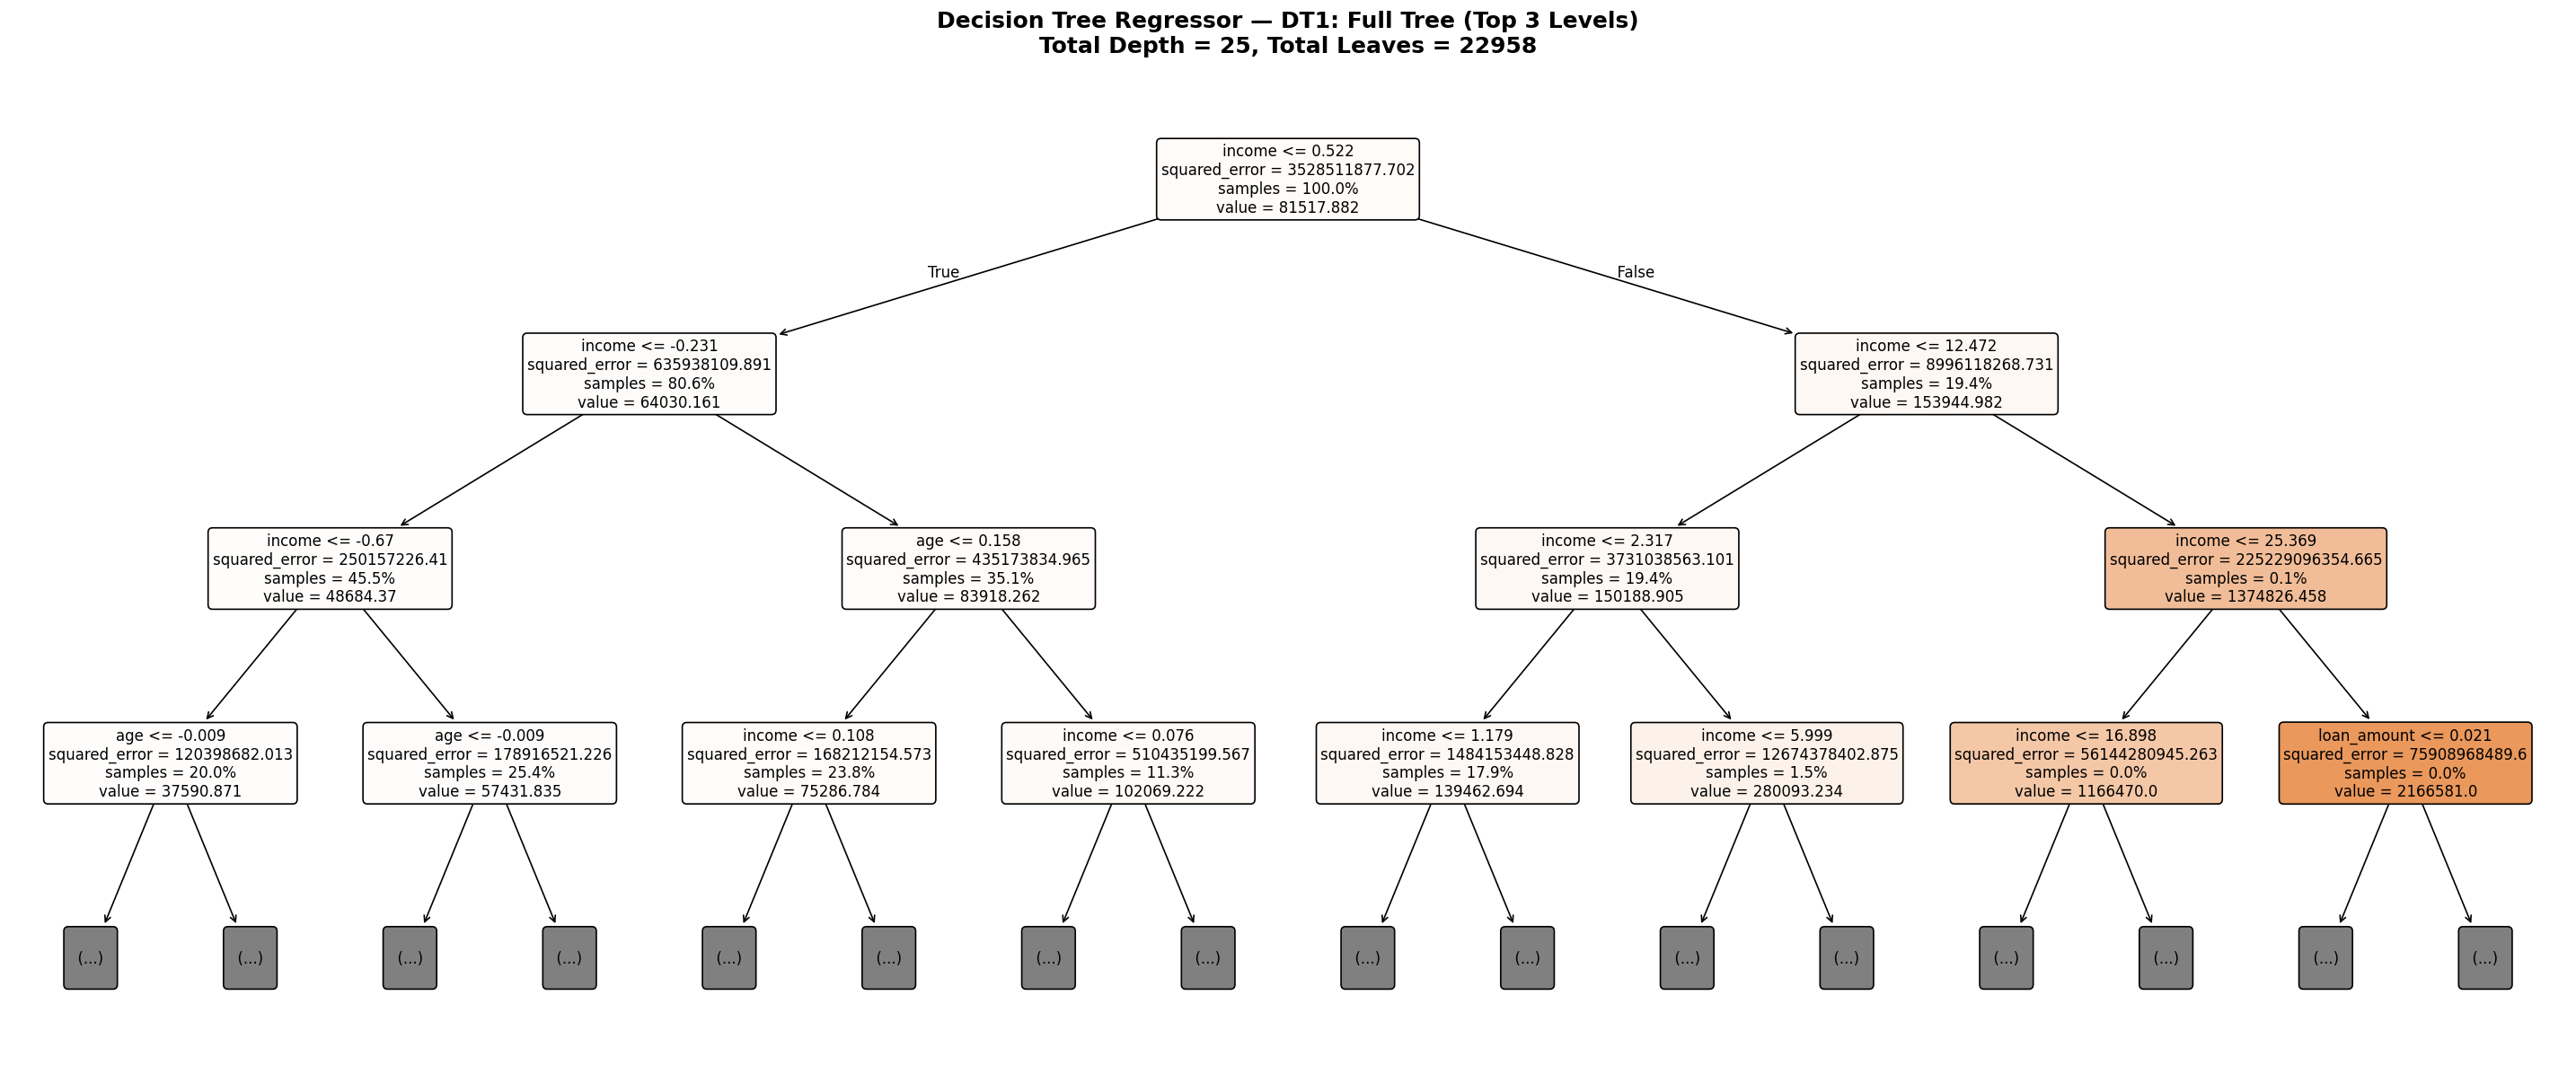

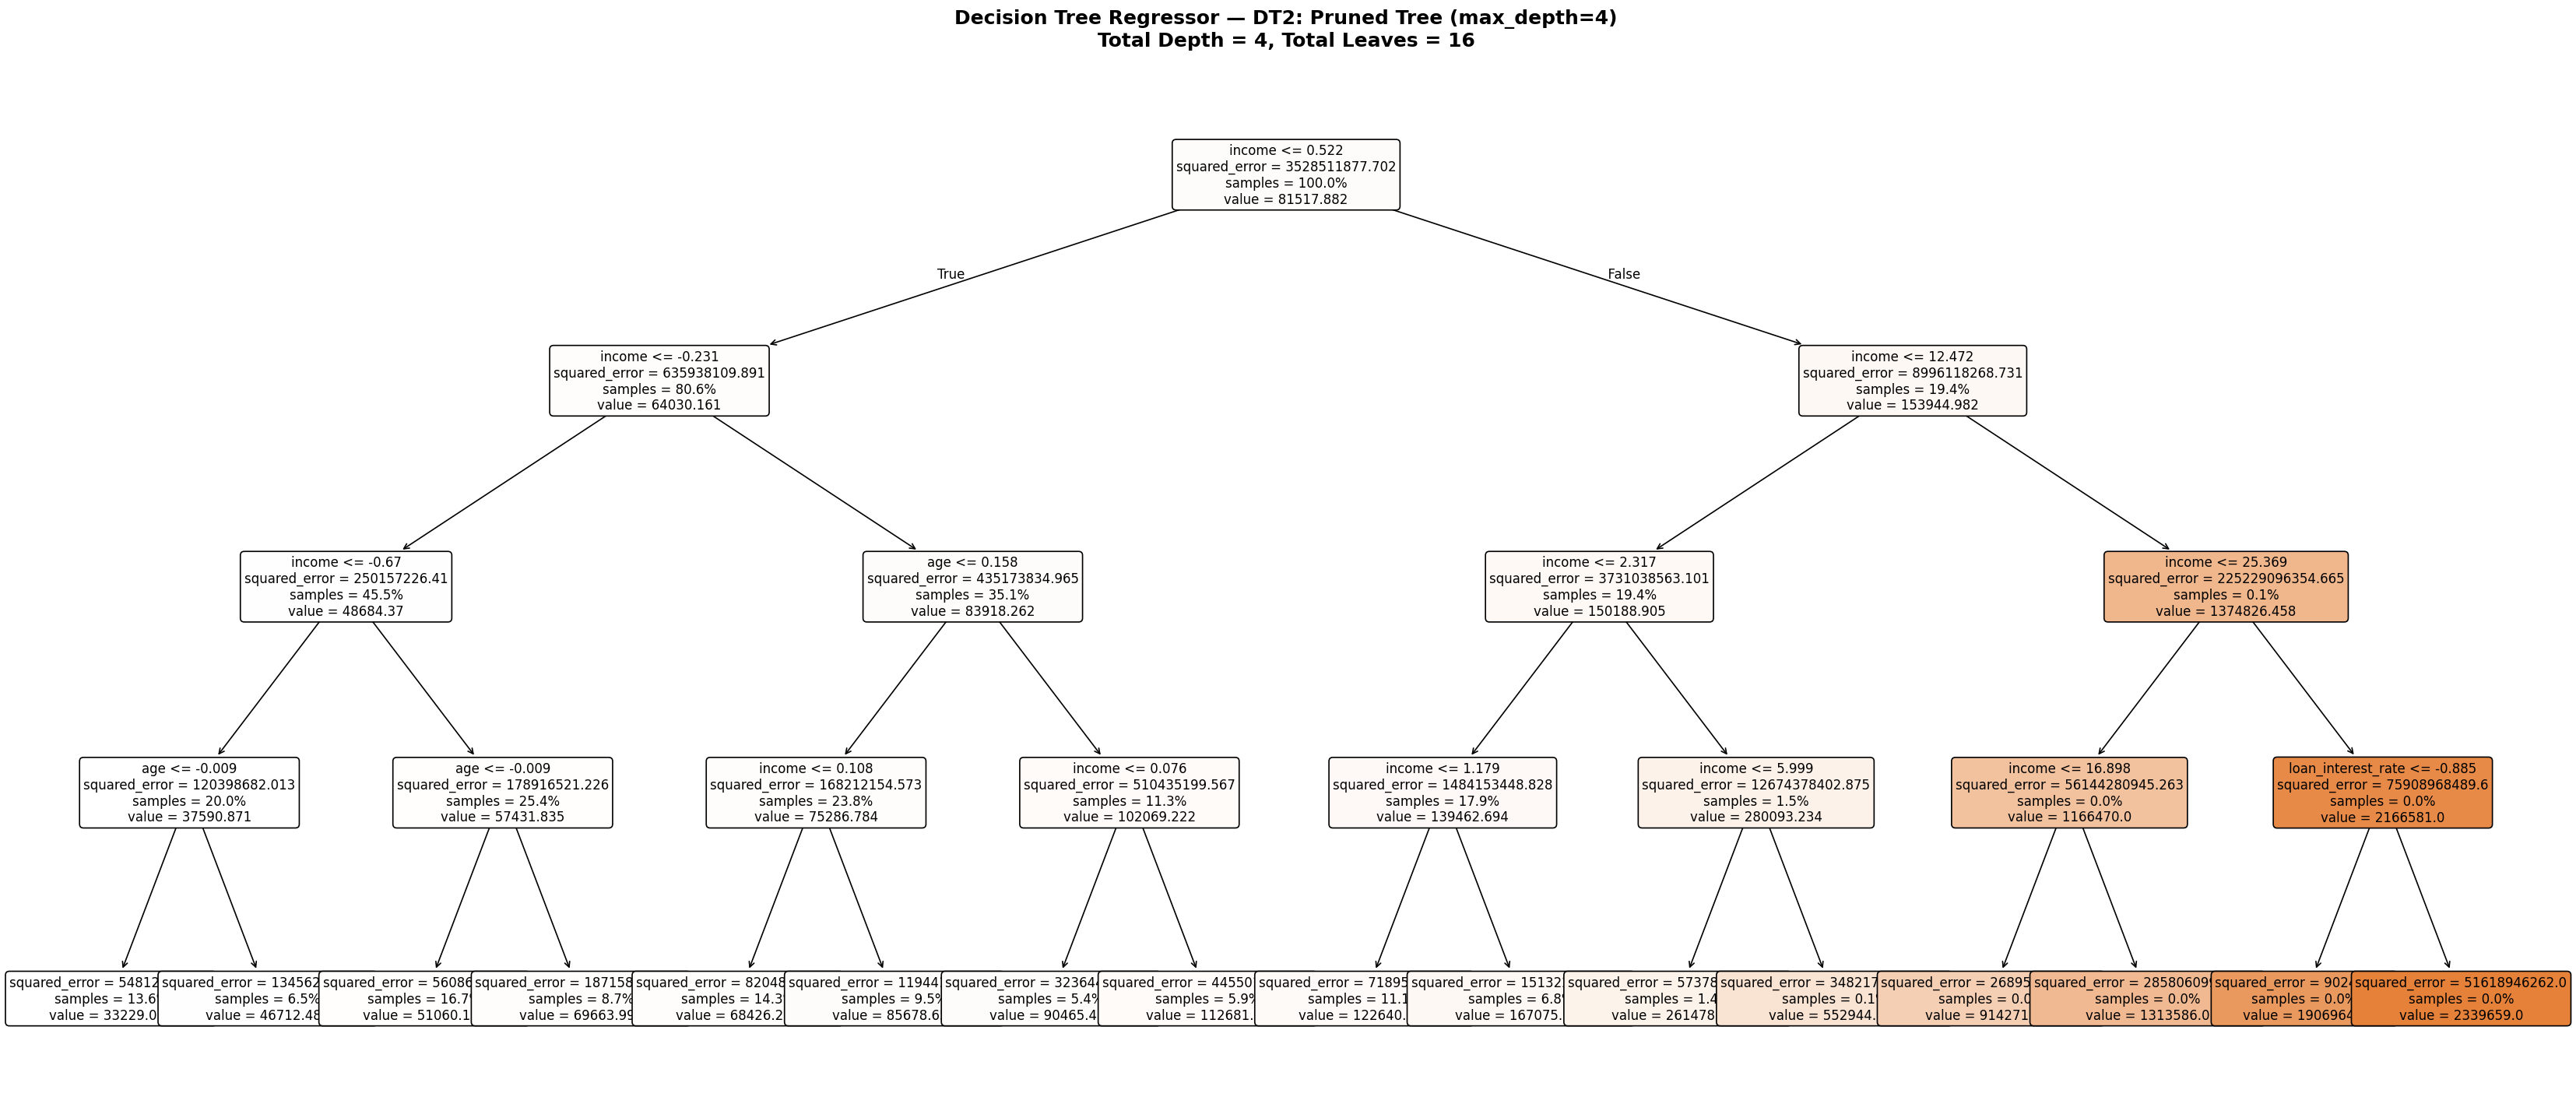

In [14]:
# Set high-quality DPI for crisp coursework screenshots
plt.rcParams['figure.dpi'] = 120

# Extract the feature names for labelling the tree nodes
feature_names = X_regression_scaled.columns.tolist()

# ── DT1: Full Tree (top 3 levels shown) ─────────────────────────────────

# Create a large, high-resolution figure for DT1
fig1, ax1 = plt.subplots(figsize=(24, 10))

# Plot the top 3 levels of DT1 using plot_tree
plot_tree(
    dt1,
    max_depth=3,                   # restrict display to 3 levels for readability
    feature_names=feature_names,   # label each split with the feature name
    filled=True,                   # colour nodes by prediction value magnitude
    rounded=True,                  # use rounded node boxes
    impurity=True,                 # show MSE impurity value at each node
    proportion=True,               # show sample proportions at each node
    fontsize=10,                   # clear, readable font for screenshots
    ax=ax1                         # draw on the pre-created axes
)

# Set the title for the DT1 visualisation — bold and descriptive
ax1.set_title(
    'Decision Tree Regressor — DT1: Full Tree (Top 3 Levels)\n'
    f'Total Depth = {dt1.get_depth()}, Total Leaves = {dt1.get_n_leaves()}',
    fontsize=15,
    fontweight='bold',
    pad=20
)

# Apply tight layout to prevent overlap
plt.tight_layout()

# Display the DT1 tree plot
plt.show()

# ── DT2: Depth-Limited Tree (full structure shown) ───────────────────────

# Create a larger figure for DT2 to accommodate all 4 levels clearly
fig2, ax2 = plt.subplots(figsize=(28, 12))

# Plot the entire DT2 tree structure
plot_tree(
    dt2,
    max_depth=None,                # show all levels (only 4 due to pruning setting)
    feature_names=feature_names,   # label each split with the feature name
    filled=True,                   # colour nodes by prediction value magnitude
    rounded=True,                  # use rounded node boxes
    impurity=True,                 # show MSE impurity value at each node
    proportion=True,               # show sample proportions at each node
    fontsize=10,                   # clear, readable font for screenshots
    ax=ax2                         # draw on the pre-created axes
)

# Set the title for the DT2 visualisation — bold and descriptive
ax2.set_title(
    'Decision Tree Regressor — DT2: Pruned Tree (max_depth=4)\n'
    f'Total Depth = {dt2.get_depth()}, Total Leaves = {dt2.get_n_leaves()}',
    fontsize=15,
    fontweight='bold',
    pad=20
)

# Apply tight layout to prevent overlap
plt.tight_layout()

# Display the DT2 tree plot
plt.show()

# Reset DPI to default after rendering tree plots
plt.rcParams['figure.dpi'] = 100


## 15. Predicted vs Actual Scatter Plots

A scatter plot of predicted values against actual values helps visualise how well each model fits the test data. Points along the diagonal line (y = x) indicate perfect predictions.

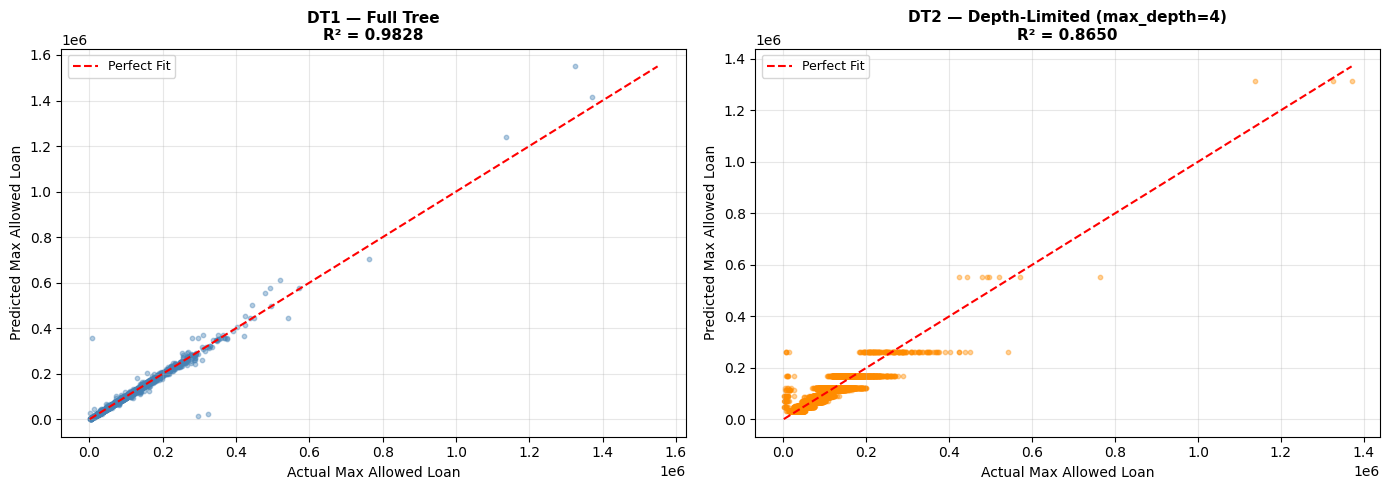

In [15]:
# Generate predictions from both models on the test set
y_pred_dt1 = dt1.predict(X_reg_test)

# Generate predictions from DT2 on the test set
y_pred_dt2 = dt2.predict(X_reg_test)

# Create side-by-side subplots for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── DT1 Scatter ───────────────────────────────────────────────────────────

# Plot actual vs predicted for DT1
axes[0].scatter(y_reg_test, y_pred_dt1, alpha=0.4, color='steelblue', s=10)

# Determine the axis limits for the diagonal reference line
min_val = min(y_reg_test.min(), y_pred_dt1.min())
max_val = max(y_reg_test.max(), y_pred_dt1.max())

# Draw the perfect-prediction diagonal reference line
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Fit')

# Set the title for the DT1 scatter plot
axes[0].set_title(f"DT1 — Full Tree\nR² = {dt1_results['R²']:.4f}", fontsize=11, fontweight='bold')

# Label the x-axis
axes[0].set_xlabel('Actual Max Allowed Loan', fontsize=10)

# Label the y-axis
axes[0].set_ylabel('Predicted Max Allowed Loan', fontsize=10)

# Add a legend
axes[0].legend(fontsize=9)

# Add a light grid for readability
axes[0].grid(alpha=0.3)

# ── DT2 Scatter ───────────────────────────────────────────────────────────

# Plot actual vs predicted for DT2
axes[1].scatter(y_reg_test, y_pred_dt2, alpha=0.4, color='darkorange', s=10)

# Determine the axis limits for the diagonal reference line
min_val2 = min(y_reg_test.min(), y_pred_dt2.min())
max_val2 = max(y_reg_test.max(), y_pred_dt2.max())

# Draw the perfect-prediction diagonal reference line
axes[1].plot([min_val2, max_val2], [min_val2, max_val2], 'r--', linewidth=1.5, label='Perfect Fit')

# Set the title for the DT2 scatter plot
axes[1].set_title(f"DT2 — Depth-Limited (max_depth=4)\nR² = {dt2_results['R²']:.4f}", fontsize=11, fontweight='bold')

# Label the x-axis
axes[1].set_xlabel('Actual Max Allowed Loan', fontsize=10)

# Label the y-axis
axes[1].set_ylabel('Predicted Max Allowed Loan', fontsize=10)

# Add a legend
axes[1].legend(fontsize=9)

# Add a light grid for readability
axes[1].grid(alpha=0.3)

# Apply tight layout to prevent label overlap between subplots
plt.tight_layout()

# Display both scatter plots
plt.show()

## 16. Select Best Regression Model

The model with the **highest R²** on the test set is identified as the best performer. A higher R² indicates the model explains more variance in the target variable.

The **lower MSE and MAE** also confirm which model provides closer predictions on average.

In [16]:
# Identify the best model name using the highest R² score
best_reg_model_name = reg_comparison_df['R²'].idxmax()

# Retrieve the best model's metrics row from the comparison DataFrame
best_reg_metrics = reg_comparison_df.loc[best_reg_model_name]

# Map model names to model objects for access
model_obj_map = {
    'DT1 — Full Tree (max_depth=None)'     : dt1,
    'DT2 — Depth-Limited (max_depth=4)'    : dt2
}

# Print a clear announcement of the best regression model
print("=" * 65)
print(f"  BEST REGRESSION MODEL (by R²): {best_reg_model_name}")
print("=" * 65)

# Print R² of the best model
print(f"  R² (R-Squared)            : {best_reg_metrics['R²']:.4f}")

# Print MSE of the best model
print(f"  MSE (Mean Squared Error)  : {best_reg_metrics['MSE']:,.2f}")

# Print MAE of the best model
print(f"  MAE (Mean Absolute Error) : {best_reg_metrics['MAE']:,.2f}")

# Print a closing separator
print("=" * 65)

# Print a brief interpretation of the result
if best_reg_model_name == 'DT1 — Full Tree (max_depth=None)':
    # Explain why the full tree might perform better on this dataset
    print("\nNote: The full tree (DT1) achieved higher R², suggesting it captures")
    print("more complex patterns. However, it risks overfitting on unseen data.")
else:
    # Explain why the pruned tree performs better
    print("\nNote: The depth-limited tree (DT2) achieved higher R², indicating")
    print("that restricting tree depth reduced overfitting and improved generalisation.")

  BEST REGRESSION MODEL (by R²): DT1 — Full Tree (max_depth=None)
  R² (R-Squared)            : 0.9828
  MSE (Mean Squared Error)  : 47,635,370.24
  MAE (Mean Absolute Error) : 1,205.86

Note: The full tree (DT1) achieved higher R², suggesting it captures
more complex patterns. However, it risks overfitting on unseen data.


---

## 17. Predict Maximum Loan Amount for a New Client

**Task 3.d — Real-World Application of the Trained Regression Model**

In this section, both trained Decision Tree regressors are used to predict the **maximum loan amount** that would be approved for a hypothetical new client.

The new client's feature vector is constructed in the **same scaled feature space** as the training data, ensuring direct compatibility with the fitted models.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Construct a Sample Client Feature Vector
# ─────────────────────────────────────────────────────────────────────────────

# Copy the first row of X_regression_scaled as a baseline template
# Using .iloc[[0]] preserves the DataFrame structure (keeps column names)
new_client = X_regression_scaled.iloc[[0]].copy()

# Inspect features available in the dataset
print("Feature columns in X_regression_scaled:")
print(new_client.columns.tolist())

# ── Modify meaningful feature values for the new client ──────────────────────

# Overwrite 'income' with a higher standardised value (+1.5 std above mean)
# Represents a relatively high-income applicant
new_client['income'] = 1.5

# Overwrite 'age' with a value slightly above the mean (+0.5 std)
# Represents a mid-career applicant (~30s)
new_client['age'] = 0.5

# Overwrite 'loan_amount' with a moderate requested amount (near mean)
# Represents a standard loan request size
new_client['loan_amount'] = 0.0

# Overwrite 'loan_interest_rate' with a low rate (−0.8 std below mean)
# Represents a client with a favourable credit profile
new_client['loan_interest_rate'] = -0.8

# Overwrite 'loan_income_ratio' with a low debt-to-income ratio (−1.0 std)
# Represents an applicant with low financial burden relative to income
new_client['loan_income_ratio'] = -1.0

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Display the New Client Feature Vector
# ─────────────────────────────────────────────────────────────────────────────

# Print a section heading for readability
print("\n" + "=" * 65)
print("  NEW CLIENT — Feature Vector (Scaled)")
print("=" * 65)

# Display the new client's feature row as a formatted DataFrame
print(new_client.to_string(index=False))

# Confirm the data type is still a pandas DataFrame (required for model input)
print(f"\nData type : {type(new_client).__name__}")

# Confirm the number of features matches training data
print(f"Features  : {new_client.shape[1]} (matches training data: {X_regression_scaled.shape[1]})")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Predict Maximum Loan Amount Using Both Trained Models
# ─────────────────────────────────────────────────────────────────────────────

# Use DT1 (full tree, max_depth=None) to predict the new client's max loan
pred_dt1 = dt1.predict(new_client)[0]

# Use DT2 (depth-limited, max_depth=4) to predict the new client's max loan
pred_dt2 = dt2.predict(new_client)[0]

# Compute the average prediction across both models as a consensus estimate
pred_avg = (pred_dt1 + pred_dt2) / 2

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Display Prediction Results
# ─────────────────────────────────────────────────────────────────────────────

# Print a clearly formatted results header
print("\n" + "=" * 65)
print("  PREDICTED MAXIMUM LOAN AMOUNT — New Client")
print("=" * 65)

# Print DT1's prediction (full tree — high-complexity model)
print(f"  DT1 — Full Tree (max_depth=None)  : £{pred_dt1:,.2f}")

# Print DT2's prediction (pruned tree — regularised model)
print(f"  DT2 — Pruned Tree (max_depth=4)   : £{pred_dt2:,.2f}")

# Print the average of both predictions as a balanced estimate
print(f"  Average Prediction (DT1 + DT2)/2  : £{pred_avg:,.2f}")

# Print closing separator
print("=" * 65)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Print an Interpretation of the Predictions
# ─────────────────────────────────────────────────────────────────────────────

# Summarise what the predictions represent and how they were derived
print("\nInterpretation:")
print("  Both predictions are derived from patterns learned during training")
print("  on approved loan records (max_allowed_loan > 0).")
print("  DT1 (full tree) memorises fine-grained patterns in training data.")
print("  DT2 (pruned tree) generalises better to unseen applicant profiles.")
print("  The average provides a balanced, consensus-based estimate.")
print("  All feature values are in standardised (z-score) scale, matching")
print("  the preprocessing applied in Notebook 1.")


Feature columns in X_regression_scaled:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

  NEW CLIENT — Feature Vector (Scaled)
 age  income  home_ownership  emplyment_length  loan_intent  loan_amount  loan_interest_rate  loan_income_ratio  payment_default_on_file  credit_history_length
 0.5     1.5             1.0         -0.466397    -0.897825          0.0                -0.8               -1.0                 -0.37146                1.29469

Data type : DataFrame
Features  : 10 (matches training data: 10)

  PREDICTED MAXIMUM LOAN AMOUNT — New Client
  DT1 — Full Tree (max_depth=None)  : £183,719.00
  DT2 — Pruned Tree (max_depth=4)   : £167,075.80
  Average Prediction (DT1 + DT2)/2  : £175,397.40

Interpretation:
  Both predictions are derived from patterns learned during training
  on approved loan records (max_allowed_loan > 0).
  DT1 (full tree) me

---

## 17. Predict Maximum Loan Amount for a New Client

**Task 3.d — Real-World Application of the Trained Regression Model**

In this section, both trained Decision Tree regressors are used to predict the **maximum loan amount** that would be approved for a hypothetical new client.

The new client's feature vector is constructed in the **same scaled feature space** as the training data, ensuring direct compatibility with the fitted models.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Construct a Sample Client Feature Vector
# ─────────────────────────────────────────────────────────────────────────────

# Copy the first row of X_regression_scaled as a baseline template
# Using .iloc[[0]] preserves the DataFrame structure (keeps column names)
new_client = X_regression_scaled.iloc[[0]].copy()

# Inspect features available in the dataset
print("Feature columns in X_regression_scaled:")
print(new_client.columns.tolist())

# ── Modify meaningful feature values for the new client ──────────────────────

# Overwrite 'income' with a higher standardised value (+1.5 std above mean)
# Represents a relatively high-income applicant
new_client['income'] = 1.5

# Overwrite 'age' with a value slightly above the mean (+0.5 std)
# Represents a mid-career applicant (~30s)
new_client['age'] = 0.5

# Overwrite 'loan_amount' with a moderate requested amount (near mean)
# Represents a standard loan request size
new_client['loan_amount'] = 0.0

# Overwrite 'loan_interest_rate' with a low rate (−0.8 std below mean)
# Represents a client with a favourable credit profile
new_client['loan_interest_rate'] = -0.8

# Overwrite 'loan_income_ratio' with a low debt-to-income ratio (−1.0 std)
# Represents an applicant with low financial burden relative to income
new_client['loan_income_ratio'] = -1.0

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Display the New Client Feature Vector
# ─────────────────────────────────────────────────────────────────────────────

# Print a section heading for readability
print("\n" + "=" * 65)
print("  NEW CLIENT — Feature Vector (Scaled)")
print("=" * 65)

# Display the new client's feature row as a formatted DataFrame
print(new_client.to_string(index=False))

# Confirm the data type is still a pandas DataFrame (required for model input)
print(f"\nData type : {type(new_client).__name__}")

# Confirm the number of features matches training data
print(f"Features  : {new_client.shape[1]} (matches training data: {X_regression_scaled.shape[1]})")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Predict Maximum Loan Amount Using Both Trained Models
# ─────────────────────────────────────────────────────────────────────────────

# Use DT1 (full tree, max_depth=None) to predict the new client's max loan
pred_dt1 = dt1.predict(new_client)[0]

# Use DT2 (depth-limited, max_depth=4) to predict the new client's max loan
pred_dt2 = dt2.predict(new_client)[0]

# Compute the average prediction across both models as a consensus estimate
pred_avg = (pred_dt1 + pred_dt2) / 2

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Display Prediction Results
# ─────────────────────────────────────────────────────────────────────────────

# Print a clearly formatted results header
print("\n" + "=" * 65)
print("  PREDICTED MAXIMUM LOAN AMOUNT — New Client")
print("=" * 65)

# Print DT1's prediction (full tree — high-complexity model)
print(f"  DT1 — Full Tree (max_depth=None)  : £{pred_dt1:,.2f}")

# Print DT2's prediction (pruned tree — regularised model)
print(f"  DT2 — Pruned Tree (max_depth=4)   : £{pred_dt2:,.2f}")

# Print the average of both predictions as a balanced estimate
print(f"  Average Prediction (DT1 + DT2)/2  : £{pred_avg:,.2f}")

# Print closing separator
print("=" * 65)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Print an Interpretation of the Predictions
# ─────────────────────────────────────────────────────────────────────────────

# Summarise what the predictions represent and how they were derived
print("\nInterpretation:")
print("  Both predictions are derived from patterns learned during training")
print("  on approved loan records (max_allowed_loan > 0).")
print("  DT1 (full tree) memorises fine-grained patterns in training data.")
print("  DT2 (pruned tree) generalises better to unseen applicant profiles.")
print("  The average provides a balanced, consensus-based estimate.")
print("  All feature values are in standardised (z-score) scale, matching")
print("  the preprocessing applied in Notebook 1.")


Feature columns in X_regression_scaled:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

  NEW CLIENT — Feature Vector (Scaled)
 age  income  home_ownership  emplyment_length  loan_intent  loan_amount  loan_interest_rate  loan_income_ratio  payment_default_on_file  credit_history_length
 0.5     1.5             1.0         -0.466397    -0.897825          0.0                -0.8               -1.0                 -0.37146                1.29469

Data type : DataFrame
Features  : 10 (matches training data: 10)

  PREDICTED MAXIMUM LOAN AMOUNT — New Client
  DT1 — Full Tree (max_depth=None)  : £183,719.00
  DT2 — Pruned Tree (max_depth=4)   : £167,075.80
  Average Prediction (DT1 + DT2)/2  : £175,397.40

Interpretation:
  Both predictions are derived from patterns learned during training
  on approved loan records (max_allowed_loan > 0).
  DT1 (full tree) me

---
## Summary

### Part 1 — Ensemble Classification

| Step | Action |
|------|--------|
| 1 | Loaded preprocessed classification data from Notebook 1 |
| 2 | Imported all required libraries |
| 3 | Split data: 80% train / 20% test, stratified, `random_state=42` |
| 4 | Built VotingClassifier with Logistic Regression + KNN (`voting='soft'`) |
| 5 | Trained the ensemble |
| 6 | Evaluated: Confusion Matrix, Classification Report, Accuracy, Recall (Reject class), Precision, F1, AUC |
| 7 | Plotted ROC curve |

### Part 2 — Decision Tree Regression

| Step | Action |
|------|--------|
| 8 | Loaded and verified regression variables |
| 9 | Split regression data: 80% train / 20% test |
| 10 | Built DT1 (full tree) and DT2 (max_depth=4) |
| 11 | Trained both models |
| 12 | Evaluated: MSE, MAE, R² for each model |
| 13 | Compared models in a summary table sorted by R² |
| 14 | Visualised both trees using `plot_tree` |
| 15 | Plotted Predicted vs Actual scatter plots |
| 16 | Selected best model based on R² |
| 17 | Predicted max loan amount for a new client using DT1 and DT2 |

---
*End of Notebook 3*